Здесь я экспериментирую с feature extraction. Я и тренирую здесь простые модели, но только для оценки полезности признаков, разработкой собственно модели можно будет заняться только позднее.

In [157]:
import polars as pl
dataset = pl.read_csv(
    '../data/processed/dataset_clean_onehot_label.csv'
)


In [158]:
SEED = 42


In [159]:
dataset.columns


['StimSite',
 'Stimulus',
 'RT_start',
 'Response_annot',
 'Response_transcription_annot',
 'speech arrest',
 'аномия',
 'дизартрия',
 'задержка',
 'нет',
 'поиск слова',
 'семантическая парафазия',
 'фонетическая парафазия',
 'Error_type_annot',
 'error_type_label']

In [160]:
dataset_0 = dataset[[
    'Stimulus',
    'RT_start',
    'Response_annot',
    'error_type_label'
    ]]\

dataset_0[['RT_start']] = dataset_0[['RT_start']]\
                          .fill_null(strategy='zero')



Различные способы заполнения слабо влияют на метрики по результатам части 1, но при заполнении нулями метрики для классов, которые ожидаемо выявляются по признаку `RT_start`, оказываются немного выше.

# 1. Длина ответа относительно длины стимула

In [161]:
dataset_1 = dataset_0.with_columns(
                            (pl.col('Response_annot').str.len_chars() /
                            pl.col('Stimulus').str.len_chars())\
                            .fill_null(0)\
                            .alias('relative_length')
                            )


In [162]:
from json import load

error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
print(*error_type_ids.items(), sep='\n')
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


('speech arrest', 1)
('аномия', 2)
('дизартрия', 3)
('задержка', 4)
('нет', 0)
('поиск слова', 5)
('семантическая парафазия', 6)
('фонетическая парафазия', 7)


In [163]:
X = dataset_1[['relative_length', 'RT_start']]
y = dataset_1['error_type_label']




In [164]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks
import numpy as np

def evaluate(X, y):
    # relative_length и RT_start — разного масштаба, для
    # линейных моделей здесь был бы скейлер
    pipeline_1 = Pipeline([
        ('classifier', RandomForestClassifier(random_state=SEED)
        )
    ])
    k = 5
    stratified_k_fold = StratifiedKFold(n_splits = k, # test 20%
                                        shuffle = True,
                                        random_state=SEED)

    f1s = np.zeros((k, 8))
    confusion_matrices = np.zeros((k, 8, 8))

    for i, (train_mask, test_mask) in\
                    enumerate(stratified_k_fold.split(X, y)):
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        pipeline_1.fit(X_train, y_train)
        predictions = pipeline_1.predict(X_test)
        f1s[i] = f1_score(y_test, predictions, average=None)
        confusion_matrices[i] = confusion_matrix(y_test, predictions)

    np.set_printoptions(suppress=True)

    print(*((name, f1.round(4).item())
            for name, f1
            in zip(error_type_ids_to_names, f1s.mean(axis=0))), sep='\n')
    
    confusion_matrix_mean = confusion_matrices.mean(axis = 0).round(2)
    confusion_matrix_normalized = confusion_matrix_mean / \
                    confusion_matrix_mean.sum(axis=1, keepdims=True)
    imshow(confusion_matrix_normalized)
    ylabel('Истина')
    xlabel('Предсказание')
    yticks(range(8), error_type_ids_to_names)
    xticks(range(8), error_type_ids_to_names, rotation=90)




('нет', 0.9529)
('speech arrest', 0.0)
('аномия', 0.7904)
('дизартрия', 0.0939)
('задержка', 0.5235)
('поиск слова', 0.2002)
('семантическая парафазия', 0.1613)
('фонетическая парафазия', 0.0463)


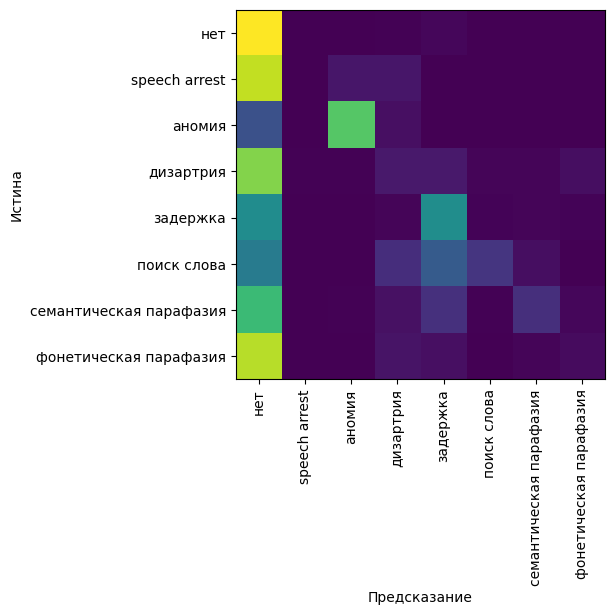

In [165]:
evaluate(X, y)


Модель лишь по этим двум признакам уже хорошо определяет случаи, когда ошибки нет. Также по относительной длине ответа и по задержке она неплохо определяет аномию и задержку, хотя последнюю при наличии RT_start должно быть проще определять. Как ни странно, модель не справляется со случаями speech arrest: хотя у них есть явный признак в виде нулевой длины ответа. Это может быть связано с их малым количеством в датасете и с ошибками или особенностями в разметке этих немногих примеров:

In [ ]:
speech_arrest_points = dataset_1.filter(pl.col('error_type_label') == 1)
print(len(speech_arrest_points))
display(speech_arrest_points.filter(pl.col('relative_length') != 0))


Видимо, некоторые типы ошибок могут быть сопряжены с характерными символами в размеченном ответе. Впрочем, на это не следует полагаться, так как решение, делающее так, не будет работать на датасете с другими стандартами разметки (например, на полученном автоматической транскрипцией).

# 2. Расстояние Левенштейна между стимулом и ответом

Сначала посмотрим на полезность доли вставок, удалений и замен. Доли, потому что стимулы могут быть разной длины, и для них будет в разной степени критично одно и то же абсолютное количество замен.

In [167]:
from rapidfuzz.distance import Levenshtein

def indelrep(stimulus, response) -> tuple[int, int, int]:
    edit_operations = Levenshtein.editops(stimulus, response)
    operation_counts = [0] * 3
    operation_ids = dict(zip(['insert', 'delete', 'replace'], range(3)))
    for tag, _, _ in edit_operations:
        operation_counts[operation_ids[tag]] += 1
    return tuple(count / len(stimulus) for count in operation_counts)

print(indelrep('роман', 'роамн'))


(0.2, 0.2, 0.0)


In [168]:
dataset_2 = dataset_1
dataset_2[['Response_annot']] =\
    dataset_2[['Response_annot']].fill_null('')


In [169]:
dataset_2 = dataset_2.with_columns(
    pl.struct(['Stimulus', 'Response_annot'])
    .map_elements(
        lambda s: indelrep(s['Stimulus'], s['Response_annot']), 
        return_dtype=pl.Struct([
            pl.Field('insertions', pl.Float64),
            pl.Field('deletions', pl.Float64),
            pl.Field('replacements', pl.Float64)
        ])
    )
    .alias('edit_distance_components')
).unnest('edit_distance_components')


In [ ]:
dataset_2.sample(10)


('нет', 0.9582)
('speech arrest', 0.0)
('аномия', 0.7731)
('дизартрия', 0.1441)
('задержка', 0.5514)
('поиск слова', 0.2598)
('семантическая парафазия', 0.3138)
('фонетическая парафазия', 0.2758)


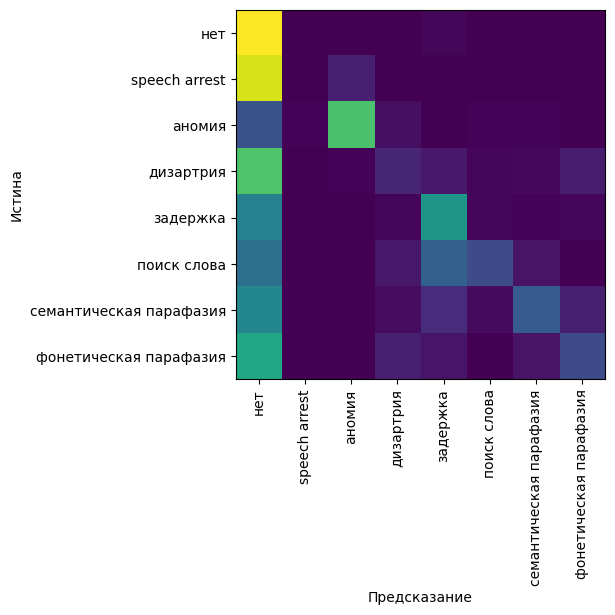

In [171]:
X = dataset_2[['RT_start', 'relative_length',
               'insertions', 'deletions', 'replacements']]
y = dataset_2['error_type_label']
evaluate(X, y)


Как и предполагалось, стало лучше с нахождением фонетической парафазии и, в меньшей степени, дизартрии, но всё ещё не так хорошо. Без моего намерения, хотя и объяснимо, поднялась метрика для семантической парафазии и поиска слова.

